In [1]:
%pip install tensorflow-hub
%pip install git+https://github.com/tensorflow/docs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/tensorflow/docs to c:\users\hp\appdata\local\temp\pip-req-build-u7754ki6
  Resolved https://github.com/tensorflow/docs to commit a8576cef38b7182e6228d7aafca8ef51754ab9e8
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached astor-0.8.1-py2.py3-none-any.whl (27 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
  Using cached PyYAML-6.0.2-cp38-cp38-win_amd64.whl (162 kB)
INFO: pip is looking at multiple versions of tensorflow-docs to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs 'C:\Users\HP\AppData\Local\Temp\pip-req-build-u7754ki6'
ERROR: Package 'tensorflow-docs' requires a different Python: 3.8.0 not in '>=3.9'

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install imageio


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import os

# Import matplotlib libraries
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patches as patches

# Some modules to display an animation using imageio.
import imageio
from IPython.display import HTML, display

In [3]:
# Dictionary that maps from joint names to keypoint indices.
KEYPOINT_DICT = {
    'nose': 0,
    'left_eye': 1,
    'right_eye': 2,
    'left_ear': 3,
    'right_ear': 4,
    'left_shoulder': 5,
    'right_shoulder': 6,
    'left_elbow': 7,
    'right_elbow': 8,
    'left_wrist': 9,
    'right_wrist': 10,
    'left_hip': 11,
    'right_hip': 12,
    'left_knee': 13,
    'right_knee': 14,
    'left_ankle': 15,
    'right_ankle': 16
}

# Maps bones to a matplotlib color name.
KEYPOINT_EDGE_INDS_TO_COLOR = {
    (0, 1): 'm',
    (0, 2): 'c',
    (1, 3): 'm',
    (2, 4): 'c',
    (0, 5): 'm',
    (0, 6): 'c',
    (5, 7): 'm',
    (7, 9): 'm',
    (6, 8): 'c',
    (8, 10): 'c',
    (5, 6): 'y',
    (5, 11): 'm',
    (6, 12): 'c',
    (11, 12): 'y',
    (11, 13): 'm',
    (13, 15): 'm',
    (12, 14): 'c',
    (14, 16): 'c'
}

def _keypoints_and_edges_for_display(keypoints_with_scores,
                                     height,
                                     width,
                                     keypoint_threshold=0.11):
  """Returns high confidence keypoints and edges for visualization.

  Args:
    keypoints_with_scores: A numpy array with shape [1, 1, 17, 3] representing
      the keypoint coordinates and scores returned from the MoveNet model.
    height: height of the image in pixels.
    width: width of the image in pixels.
    keypoint_threshold: minimum confidence score for a keypoint to be
      visualized.

  Returns:
    A (keypoints_xy, edges_xy, edge_colors) containing:
      * the coordinates of all keypoints of all detected entities;
      * the coordinates of all skeleton edges of all detected entities;
      * the colors in which the edges should be plotted.
  """
  keypoints_all = []
  keypoint_edges_all = []
  edge_colors = []
  num_instances, _, _, _ = keypoints_with_scores.shape
  for idx in range(num_instances):
    kpts_x = keypoints_with_scores[0, idx, :, 1]
    kpts_y = keypoints_with_scores[0, idx, :, 0]
    kpts_scores = keypoints_with_scores[0, idx, :, 2]
    kpts_absolute_xy = np.stack(
        [width * np.array(kpts_x), height * np.array(kpts_y)], axis=-1)
    kpts_above_thresh_absolute = kpts_absolute_xy[
        kpts_scores > keypoint_threshold, :]
    keypoints_all.append(kpts_above_thresh_absolute)

    for edge_pair, color in KEYPOINT_EDGE_INDS_TO_COLOR.items():
      if (kpts_scores[edge_pair[0]] > keypoint_threshold and
          kpts_scores[edge_pair[1]] > keypoint_threshold):
        x_start = kpts_absolute_xy[edge_pair[0], 0]
        y_start = kpts_absolute_xy[edge_pair[0], 1]
        x_end = kpts_absolute_xy[edge_pair[1], 0]
        y_end = kpts_absolute_xy[edge_pair[1], 1]
        line_seg = np.array([[x_start, y_start], [x_end, y_end]])
        keypoint_edges_all.append(line_seg)
        edge_colors.append(color)
  if keypoints_all:
    keypoints_xy = np.concatenate(keypoints_all, axis=0)
  else:
    keypoints_xy = np.zeros((0, 17, 2))

  if keypoint_edges_all:
    edges_xy = np.stack(keypoint_edges_all, axis=0)
  else:
    edges_xy = np.zeros((0, 2, 2))
  return keypoints_xy, edges_xy, edge_colors


def draw_prediction_on_image(
    image, keypoints_with_scores, crop_region=None, close_figure=False,
    output_image_height=None):
  """Draws the keypoint predictions on image.

  Args:
    image: A numpy array with shape [height, width, channel] representing the
      pixel values of the input image.
    keypoints_with_scores: A numpy array with shape [1, 1, 17, 3] representing
      the keypoint coordinates and scores returned from the MoveNet model.
    crop_region: A dictionary that defines the coordinates of the bounding box
      of the crop region in normalized coordinates (see the init_crop_region
      function below for more detail). If provided, this function will also
      draw the bounding box on the image.
    output_image_height: An integer indicating the height of the output image.
      Note that the image aspect ratio will be the same as the input image.

  Returns:
    A numpy array with shape [out_height, out_width, channel] representing the
    image overlaid with keypoint predictions.
  """
  height, width, channel = image.shape
  aspect_ratio = float(width) / height
  fig, ax = plt.subplots(figsize=(12 * aspect_ratio, 12))
  # To remove the huge white borders
  fig.tight_layout(pad=0)
  ax.margins(0)
  ax.set_yticklabels([])
  ax.set_xticklabels([])
  plt.axis('off')

  im = ax.imshow(image)
  line_segments = LineCollection([], linewidths=(4), linestyle='solid')
  ax.add_collection(line_segments)
  # Turn off tick labels
  scat = ax.scatter([], [], s=60, color='#FF1493', zorder=3)

  (keypoint_locs, keypoint_edges,
   edge_colors) = _keypoints_and_edges_for_display(
       keypoints_with_scores, height, width)

  line_segments.set_segments(keypoint_edges)
  line_segments.set_color(edge_colors)
  if keypoint_edges.shape[0]:
    line_segments.set_segments(keypoint_edges)
    line_segments.set_color(edge_colors)
  if keypoint_locs.shape[0]:
    scat.set_offsets(keypoint_locs)

  if crop_region is not None:
    xmin = max(crop_region['x_min'] * width, 0.0)
    ymin = max(crop_region['y_min'] * height, 0.0)
    rec_width = min(crop_region['x_max'], 0.99) * width - xmin
    rec_height = min(crop_region['y_max'], 0.99) * height - ymin
    rect = patches.Rectangle(
        (xmin,ymin),rec_width,rec_height,
        linewidth=1,edgecolor='b',facecolor='none')
    ax.add_patch(rect)

  fig.canvas.draw()
  image_from_plot = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
  image_from_plot = image_from_plot.reshape(
      fig.canvas.get_width_height()[::-1] + (3,))
  plt.close(fig)
  if output_image_height is not None:
    output_image_width = int(output_image_height / height * width)
    image_from_plot = cv2.resize(
        image_from_plot, dsize=(output_image_width, output_image_height),
         interpolation=cv2.INTER_CUBIC)
  return image_from_plot

def progress(value, max=100):
  return HTML("""
      <progress
          value='{value}'
          max='{max}',
          style='width: 100%'
      >
          {value}
      </progress>
  """.format(value=value, max=max))

In [4]:
model_name = "movenet_thunder"

if "tflite" in model_name:
  if "movenet_lightning_f16" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/lightning/tflite/float16/4?lite-format=tflite
    input_size = 192
  elif "movenet_thunder_f16" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/thunder/tflite/float16/4?lite-format=tflite
    input_size = 256
  elif "movenet_lightning_int8" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/lightning/tflite/int8/4?lite-format=tflite
    input_size = 192
  elif "movenet_thunder_int8" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/thunder/tflite/int8/4?lite-format=tflite
    input_size = 256
  else:
    raise ValueError("Unsupported model name: %s" % model_name)

  # Initialize the TFLite interpreter
  interpreter = tf.lite.Interpreter(model_path="model.tflite")
  interpreter.allocate_tensors()

  def movenet(input_image):
    """Runs detection on an input image.

    Args:
      input_image: A [1, height, width, 3] tensor represents the input image
        pixels. Note that the height/width should already be resized and match the
        expected input resolution of the model before passing into this function.

    Returns:
      A [1, 1, 17, 3] float numpy array representing the predicted keypoint
      coordinates and scores.
    """
    # TF Lite format expects tensor type of uint8.
    input_image = tf.cast(input_image, dtype=tf.uint8)
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    interpreter.set_tensor(input_details[0]['index'], input_image.numpy())
    # Invoke inference.
    interpreter.invoke()
    # Get the model prediction.
    keypoints_with_scores = interpreter.get_tensor(output_details[0]['index'])
    return keypoints_with_scores

else:
  if "movenet_lightning" in model_name:
    module = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
    input_size = 192
  elif "movenet_thunder" in model_name:
    module = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
    input_size = 256
  else:
    raise ValueError("Unsupported model name: %s" % model_name)

  def movenet(input_image):
    """Runs detection on an input image.

    Args:
      input_image: A [1, height, width, 3] tensor represents the input image
        pixels. Note that the height/width should already be resized and match the
        expected input resolution of the model before passing into this function.

    Returns:
      A [1, 1, 17, 3] float numpy array representing the predicted keypoint
      coordinates and scores.
    """
    model = module.signatures['serving_default']

    # SavedModel format expects tensor type of int32.
    input_image = tf.cast(input_image, dtype=tf.int32)
    # Run model inference.
    outputs = model(input_image)
    # Output is a [1, 1, 17, 3] tensor.
    keypoints_with_scores = outputs['output_0'].numpy()
    return keypoints_with_scores

In [5]:
def load_movenet(image_path):
    # Load the input image.
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image)

    # Resize and pad the image to keep the aspect ratio and fit the expected size.
    input_image = tf.expand_dims(image, axis=0)
    input_image = tf.image.resize_with_pad(input_image, input_size, input_size)

    # Run model inference.
    keypoints_with_scores = movenet(input_image)
    
    return keypoints_with_scores

def visualize_movenet(keypoints_with_scores, image_path,  output_path):
    
    # Load the input image.
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image)
    
    # Visualize the predictions with image.
    display_image = tf.expand_dims(image, axis=0)
    display_image = tf.cast(tf.image.resize_with_pad(
        display_image, 1280, 1280), dtype=tf.int32)
    output_overlay = draw_prediction_on_image(
        np.squeeze(display_image.numpy(), axis=0), keypoints_with_scores)

    # plt.figure(figsize=(5, 5))
    # plt.imshow(output_overlay)
    # _ = plt.axis('off')

    # Save the overlay
    cv2.imwrite(output_path, cv2.cvtColor(output_overlay, cv2.COLOR_RGB2BGR))


In [6]:
def normalize_hip_center(keypoints_with_scores):
    
    # Get all keypoints
    keypoints = keypoints_with_scores[0, 0, :, :2]  # shape: (17, 2)
    scores = keypoints_with_scores[0, 0, :, 2]      # Confidence scores
    
    confidence_threshold = 0.3
    
    # Get center of body (hip)
    left_hip = keypoints[11]
    right_hip = keypoints[12]
    
    # Get the hip center (if confidence > threshold)
    if scores[11] > confidence_threshold and scores[12] > confidence_threshold :
        hip_center = (left_hip + right_hip) / 2
    else:
        # Fallback: use the mean of all the keypoints
        valid_indices = np.where(scores > confidence_threshold)[0]
        hip_center = np.mean(keypoints[valid_indices], axis=0) if len(valid_indices) > 0 else np.zeros(2)
    
    # Change the keypoints to hip oriented
    keypoints_centered = keypoints - hip_center
    
    # Height estimation from shoulder to hip
    left_shoulder = keypoints[5]
    right_shoulder = keypoints[6]
    
    # Normalization with height estimation (if confidence > threshold)
    if scores[5] > confidence_threshold and scores[6] > confidence_threshold and np.linalg.norm(left_shoulder - right_shoulder) > 0:
        shoulder_center = (left_shoulder + right_shoulder) / 2
        body_height = np.linalg.norm(shoulder_center - hip_center)
        keypoints_normalized = keypoints_centered / body_height
    else:
        # Fallback: use a normal case body_height shoulder-to-hip 0.3 - 0.5
        keypoints_normalized = keypoints_centered / 0.4

    
    return keypoints_normalized


In [ ]:
# Tentukan direktori yang ingin Anda periksa
gerakan = ["Berdiri", "Sujud", "Duduk"]
directory_path = "Hasil/data_frame/"+gerakan[0]
final_path = "Hasil/final_frame/"+gerakan[0]+"/final"
image_path = directory_path+"/frame_"

# Dapatkan daftar file dalam direktori
files = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]

# Lakukan perulangan sebanyak jumlah file
for i, file in enumerate(files, start=1):
    visualize_movenet(load_movenet(image_path+str(i-1)+".jpg"), image_path+str(i-1)+".jpg", final_path+str(i-1)+".jpg")

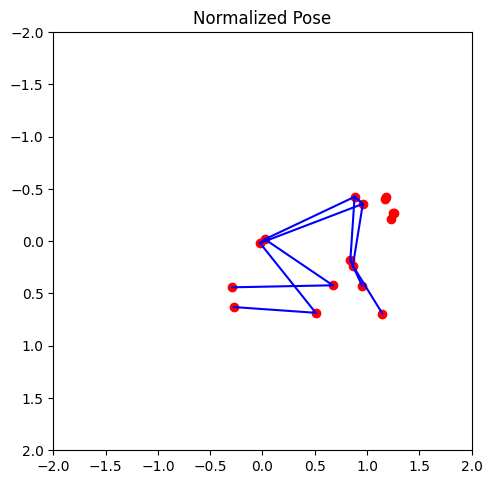

In [ ]:
normalized_keypoints = normalize_hip_center(load_movenet("File/my_salat/data_frame/frame195.jpg"))

fig = plt.figure(figsize=(5, 5), dpi=100)
ax = fig.add_subplot(1, 1, 1)

# Setting axis
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title("Normalized Pose")

# Plot titik
for x, y in normalized_keypoints:
    plt.plot(y, x, 'ro')  # titik merah

# Sambungkan titik-titik (opsional)
POSE_CONNECTIONS = [
    (5, 6), (5, 11), (6, 12),  # shoulders to hips
    (5, 7), (7, 9),  # left arm
    (6, 8), (8, 10), # right arm
    (11, 13), (13, 15),  # left leg
    (12, 14), (14, 16),  # right leg
    (11, 12), (5, 6)  # hips and shoulders
]
for a, b in POSE_CONNECTIONS:
    x1, y1 = normalized_keypoints[a]
    x2, y2 = normalized_keypoints[b]
    plt.plot([y1, y2], [x1, x2], 'b-')  # garis biru

# Jaga margin tetap
plt.tight_layout()
plt.show()


In [16]:
import matplotlib.pyplot as plt

# Tentukan direktori yang ingin Anda periksa
name_video = "my_salat"
directory_path = "File/"+name_video+"/data_frame"
final_path = "File/"+name_video+"/final1_frame/final"
image_path = directory_path+"/frame"

# Dapatkan daftar file dalam direktori
files = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]

# Lakukan perulangan sebanyak jumlah file
for i, file in enumerate(files, start=1):
    normalized_keypoints = normalize_hip_center(load_movenet(image_path+str(i-1)+".jpg"))

    fig = plt.figure(figsize=(5, 5), dpi=100)
    ax = fig.add_subplot(1, 1, 1)

    # Setting axis
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title("Normalized Pose")
    
    # Plot titik
    for x, y in normalized_keypoints:
        plt.plot(y, x, 'ro')  # titik merah

    # Sambungkan titik-titik (opsional)
    POSE_CONNECTIONS = [
        (5, 6), (5, 11), (6, 12),  # shoulders to hips
        (5, 7), (7, 9),  # left arm
        (6, 8), (8, 10), # right arm
        (11, 13), (13, 15),  # left leg
        (12, 14), (14, 16),  # right leg
        (11, 12), (5, 6)  # hips and shoulders
    ]
    for a, b in POSE_CONNECTIONS:
        x1, y1 = normalized_keypoints[a]
        x2, y2 = normalized_keypoints[b]
        plt.plot([y1, y2], [x1, x2], 'b-')  # garis biru

    # Jaga margin tetap
    plt.tight_layout()
    plt.savefig(f"{final_path}{i}.jpg")
    plt.close()


In [17]:
# Load the input image.
image_path = directory_path+"/frame195.jpg"
image = tf.io.read_file(image_path)
image = tf.image.decode_jpeg(image)

# Resize and pad the image to keep the aspect ratio and fit the expected size.
input_image = tf.expand_dims(image, axis=0)
input_image = tf.image.resize_with_pad(input_image, input_size, input_size)
keypoints_with_scores = movenet(input_image)

# Daftar nama keypoints berdasarkan urutan MoveNet
keypoint_names = [
    "Nose", "Left Eye", "Right Eye", "Left Ear", "Right Ear",
    "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
    "Left Wrist", "Right Wrist", "Left Hip", "Right Hip",
    "Left Knee", "Right Knee", "Left Ankle", "Right Ankle"
]

# Ambil semua keypoints
keypoints = keypoints_with_scores[0, 0]  # shape (17, 3)
print(keypoints_with_scores[0][0][11])

# Threshold confidence (opsional)
threshold = 0.5

# Cetak semua keypoint dengan nama
for i, (y, x, score) in enumerate(keypoints):
    name = keypoint_names[i]
    status = "✓" if score > threshold else "✗"
    print(f"{name:<15}: x={x:.3f}, y={y:.3f}, score={score:.3f} {status}")

[0.62485945 0.43103004 0.3587587 ]
Nose           : x=0.656, y=0.589, score=0.454 ✗
Left Eye       : x=0.661, y=0.577, score=0.461 ✗
Right Eye      : x=0.660, y=0.578, score=0.488 ✗
Left Ear       : x=0.648, y=0.550, score=0.573 ✓
Right Ear      : x=0.646, y=0.552, score=0.576 ✓
Left Shoulder  : x=0.592, y=0.549, score=0.479 ✗
Right Shoulder : x=0.606, y=0.562, score=0.420 ✗
Left Elbow     : x=0.584, y=0.663, score=0.608 ✓
Right Elbow    : x=0.589, y=0.672, score=0.587 ✓
Left Wrist     : x=0.605, y=0.708, score=0.171 ✗
Right Wrist    : x=0.642, y=0.758, score=0.749 ✓
Left Hip       : x=0.431, y=0.625, score=0.359 ✗
Right Hip      : x=0.422, y=0.632, score=0.521 ✓
Left Knee      : x=0.553, y=0.707, score=0.332 ✗
Right Knee     : x=0.522, y=0.757, score=0.811 ✓
Left Ankle     : x=0.372, y=0.711, score=0.336 ✗
Right Ankle    : x=0.376, y=0.746, score=0.410 ✗
